<a href="https://colab.research.google.com/github/JamesSembukuttiarachchi/rain_in_australia/blob/main/01_logistic_regression_weatherAUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RainTomorrow Prediction using Logistic Regression

## Objective
Predict whether it will rain tomorrow (`RainTomorrow`) using the Australia weather dataset.

## Why this model?
A strong, simple baseline for binary classification. It is fast, interpretable, and useful for showing how the weather features linearly influence the probability of rain tomorrow.

## Workflow covered in this notebook
1. Load and inspect the dataset
2. Clean the target and handle missing values
3. Engineer simple date-based features
4. Build a preprocessing + modeling pipeline
5. Train/test split with stratification
6. Train the model
7. Evaluate with accuracy, precision, recall, F1, ROC-AUC, confusion matrix
8. Inspect the most important patterns/features where appropriate


In [9]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)


DATA_PATH = "/weatherAUS_balanced.csv"   # keep the CSV in the same folder as this notebook, or update this path

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Shape: (220632, 23)
Columns: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0.0,0.0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0.0,0.0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0.0,0.0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0.0,0.0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0.0,0.0


Cleaned shape: (220632, 26)

Target distribution:
RainTomorrow
0.0    110316
1.0    110316
Name: count, dtype: int64

Target proportions:
RainTomorrow
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

Top missing columns (%):
Sunshine         47.51
Evaporation      43.24
Cloud3pm         38.80
Cloud9am         36.87
Pressure3pm       9.86
Pressure9am       9.85
WindGustDir       7.02
WindGustSpeed     6.96
WindDir9am        6.68
WindDir3pm        2.92
dtype: float64


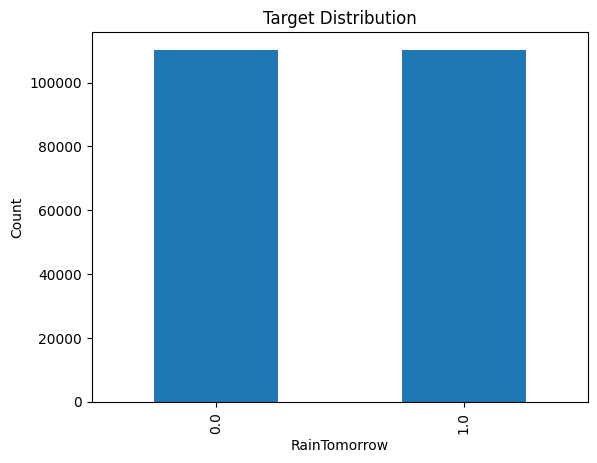

In [10]:

# Basic target cleaning
df = df.copy()
df = df.dropna(subset=["RainTomorrow"]).reset_index(drop=True)

# Binary encode target
#df["RainTomorrow"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})
#df["RainToday"] = df["RainToday"].map({"No": 0, "Yes": 1})

# Date feature engineering
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfYear"] = df["Date"].dt.dayofyear

# Drop the raw date column after feature extraction
df = df.drop(columns=["Date"])

print("Cleaned shape:", df.shape)
print("\nTarget distribution:")
print(df["RainTomorrow"].value_counts())
print("\nTarget proportions:")
print(df["RainTomorrow"].value_counts(normalize=True).round(4))

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("\nTop missing columns (%):")
print(missing_pct.head(10).round(2))

ax = df["RainTomorrow"].value_counts().plot(kind="bar", title="Target Distribution")
ax.set_xlabel("RainTomorrow")
ax.set_ylabel("Count")
plt.show()


In [11]:

X = df.drop(columns=["RainTomorrow"])
y = df["RainTomorrow"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))
print("Categorical columns:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_ohe())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Numeric feature count: 21
Categorical feature count: 4
Categorical columns: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
Train shape: (176505, 25)
Test shape: (44127, 25)


## Train Logistic Regression

In [12]:

from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

model.fit(X_train, y_train)
print("Model training complete.")


Model training complete.


## Evaluate the model

,Score
Accuracy,0.786571
Precision,0.794412
Recall,0.773240
F1-score,0.783683
ROC-AUC,0.872544



Classification Report:

              precision    recall  f1-score   support

         0.0     0.7791    0.7999    0.7894     22064
         1.0     0.7944    0.7732    0.7837     22063

    accuracy                         0.7866     44127
   macro avg     0.7868    0.7866    0.7865     44127
weighted avg     0.7868    0.7866    0.7865     44127



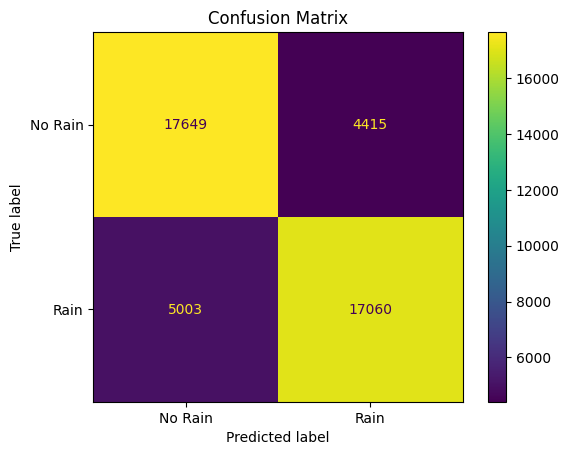

In [13]:

# Predictions
y_pred = model.predict(X_test)

# Probabilities / scores
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_test)[:, 1]
elif hasattr(model, "decision_function"):
    y_proba = model.decision_function(X_test)
else:
    y_proba = None

# Metrics
results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
}

if y_proba is not None:
    results["ROC-AUC"] = roc_auc_score(y_test, y_proba)

results_df = pd.DataFrame(results, index=["Score"]).T
display(results_df)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Rain", "Rain"])
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()


## Model-specific interpretation

In [ ]:

# Coefficient inspection (Logistic Regression)
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
      .assign(abs_coef=lambda d: d["coefficient"].abs())
      .sort_values("abs_coef", ascending=False)
)

print("Top positive contributors to RainTomorrow = Yes")
display(coef_df.sort_values("coefficient", ascending=False).head(15)[["feature", "coefficient"]])

print("Top negative contributors to RainTomorrow = Yes")
display(coef_df.sort_values("coefficient", ascending=True).head(15)[["feature", "coefficient"]])


## Short explanation of how Logistic Regression works

- Learns a weighted combination of features.
- Passes the result through a sigmoid function to estimate the probability of rain.
- Predicts the class with the higher probability.
